# NHL Shot Danger Model

End-to-end walkthrough: load real MoneyPuck shot data, engineer geometry + context features, train a calibrated logistic regression, evaluate, and produce the visuals that back the coach-facing report.

**Pipeline:**
1. Load CSV — MoneyPuck's 124-column shots file (drop empty-net shots and rows missing geometry)
2. Engineer features: distance, angle, non-linear transforms, shot-type one-hots, rebound/public rush proxy/off-wing/speed
3. Train logistic regression baseline + optional gradient boosting
4. Evaluate: ROC-AUC, log loss, Brier, calibration
5. Benchmark against MoneyPuck's own xGoal
6. Visualize: shot map, goal rate by distance/angle, danger heatmap, feature importances
7. Pull out coach-facing takeaways

In [1]:
import sys
from pathlib import Path

# Make the src/ package importable when running from notebooks/
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.features import (
    clean_data, detect_columns, engineer_features, feature_columns,
    load_shot_data, validate_columns,
)
from src.model import (
    benchmark_probabilities, calibration_table, coefficient_table, evaluate,
    feature_importance_table, split_data, train_gradient_boosting, train_logistic,
)
from src.visuals import (
    plot_calibration, plot_danger_heatmap, plot_feature_importance,
    plot_goal_rate_by_angle, plot_goal_rate_by_distance, plot_shot_map,
)

pd.set_option('display.max_columns', 80)
plt.rcParams['figure.dpi'] = 100

## 1. Load the data

Download a MoneyPuck shots CSV from [moneypuck.com/data.htm](https://moneypuck.com/data.htm) and place it at `../data/shots.csv`. See `DATA_INSTRUCTIONS.md` for step-by-step details.

The pipeline also accepts `../data/sample_shots.csv` (run `python make_sample_data.py` from the repo root) as a synthetic fallback for quick testing.

In [2]:
data_dir = Path('..') / 'data'

# Prefer real MoneyPuck data; fall back to synthetic sample
for candidate in ['shots.csv', 'sample_shots.csv']:
    path = data_dir / candidate
    if path.exists():
        break
else:
    raise FileNotFoundError(
        'No CSV found. Put a MoneyPuck shots CSV at data/shots.csv '
        '(see DATA_INSTRUCTIONS.md), or run `python make_sample_data.py`.'
    )

raw = load_shot_data(path)
print(f'Loaded {len(raw):,} rows from {path.name}')
print(f'Columns: {len(raw.columns)}')
raw.head(3)

Loaded 116,207 rows from shots.csv
Columns: 124


,shotID,arenaAdjustedShotDistance,arenaAdjustedXCord,arenaAdjustedXCordABS,arenaAdjustedYCord,arenaAdjustedYCordAbs,averageRestDifference,awayEmptyNet,awayPenalty1Length,awayPenalty1TimeLeft,awaySkatersOnIce,awayTeamCode,awayTeamGoals,defendingTeamAverageTimeOnIce,defendingTeamAverageTimeOnIceOfDefencemen,defendingTeamAverageTimeOnIceOfDefencemenSinceFaceoff,defendingTeamAverageTimeOnIceOfForwards,defendingTeamAverageTimeOnIceOfForwardsSinceFaceoff,defendingTeamAverageTimeOnIceSinceFaceoff,defendingTeamDefencemenOnIce,defendingTeamForwardsOnIce,defendingTeamMaxTimeOnIce,defendingTeamMaxTimeOnIceOfDefencemen,defendingTeamMaxTimeOnIceOfDefencemenSinceFaceoff,defendingTeamMaxTimeOnIceOfForwards,defendingTeamMaxTimeOnIceOfForwardsSinceFaceoff,defendingTeamMaxTimeOnIceSinceFaceoff,defendingTeamMinTimeOnIce,defendingTeamMinTimeOnIceOfDefencemen,defendingTeamMinTimeOnIceOfDefencemenSinceFaceoff,defendingTeamMinTimeOnIceOfForwards,defendingTeamMinTimeOnIceOfForwardsSinceFaceoff,defendingTeamMinTimeOnIceSinceFaceoff,distanceFromLastEvent,event,game_id,goal,goalieIdForShot,goalieNameForShot,homeEmptyNet,...,shootingTeamMinTimeOnIceOfDefencemen,shootingTeamMinTimeOnIceOfDefencemenSinceFaceoff,shootingTeamMinTimeOnIceOfForwards,shootingTeamMinTimeOnIceOfForwardsSinceFaceoff,shootingTeamMinTimeOnIceSinceFaceoff,shotAngle,shotAngleAdjusted,shotAnglePlusRebound,shotAnglePlusReboundSpeed,shotAngleReboundRoyalRoad,shotDistance,shotGeneratedRebound,shotGoalieFroze,shotOnEmptyNet,shotPlayContinuedInZone,shotPlayContinuedOutsideZone,shotPlayStopped,shotRebound,shotRush,shotType,shotWasOnGoal,speedFromLastEvent,team,teamCode,time,timeDifferenceSinceChange,timeSinceFaceoff,timeSinceLastEvent,timeUntilNextEvent,xCord,xCordAdjusted,xFroze,xGoal,xPlayContinuedInZone,xPlayContinuedOutsideZone,xPlayStopped,xRebound,xShotWasOnGoal,yCord,yCordAdjusted
0,0,38.0,-58.0,58.0,-22.0,22.0,0.0,0,0,0,5,CHI,0,6.4,10.0,1.0,4.0,1.0,1.0,2,3,19,19,1,10,1,1,1,1,1,1,1,1,11.000000,SHOT,20001,0,8481519,Spencer Knight,0,...,14,1,10,1,1,35.362462,35.362462,0.0,0.0,0,38.013156,0,1,0,0,0,0,0,0,WRIST,1,11.000000,HOME,FLA,76,0,1,1,1,-58,58,0.308458,0.01751,0.350448,0.253295,0.035563,0.034727,0.791506,-22,22
1,1,59.0,-33.0,33.0,-19.0,19.0,0.0,0,0,0,5,CHI,0,25.4,29.0,3.0,23.0,3.0,3.0,2,3,38,38,3,29,3,3,20,20,3,20,3,3,36.124784,SHOT,20001,0,8481519,Spencer Knight,0,...,33,3,3,3,3,18.741340,18.741340,0.0,0.0,0,59.135438,0,1,0,0,0,0,0,0,SLAP,1,12.041595,HOME,FLA,95,0,3,3,1,-33,33,0.304403,0.03672,0.356975,0.235788,0.025301,0.040814,0.738728,-19,19
2,2,45.0,55.0,55.0,-29.0,29.0,0.0,0,0,0,5,CHI,0,24.0,42.0,8.0,12.0,8.0,8.0,2,3,42,42,8,12,8,8,12,42,8,12,8,8,124.197423,MISS,20001,0,8475683,Sergei Bobrovsky,0,...,29,8,29,8,8,-40.462227,40.462227,0.0,0.0,0,44.687806,0,0,0,1,0,0,0,0,SNAP,0,15.524678,AWAY,CHI,104,0,8,8,2,55,55,0.306225,0.01603,0.358237,0.263372,0.026669,0.029466,0.831215,-29,-29


In [3]:
# Which MoneyPuck columns did we map to our canonical names?
cols = detect_columns(raw)
print(f'Detected {len(cols)} canonical columns:')
for canonical, actual in sorted(cols.items()):
    print(f'  {canonical:25s} -> {actual}')

Detected 38 canonical columns:
  angle_change_rebound      -> shotAnglePlusRebound
  away_goals                -> awayTeamGoals
  away_skaters              -> awaySkatersOnIce
  distance_from_last        -> distanceFromLastEvent
  empty_net                 -> shotOnEmptyNet
  event                     -> event
  game_id                   -> game_id
  goal                      -> goal
  goalie_name               -> goalieNameForShot
  home_goals                -> homeTeamGoals
  home_skaters              -> homeSkatersOnIce
  is_home_team              -> isHomeTeam
  is_playoff                -> isPlayoffGame
  last_event_category       -> lastEventCategory
  off_wing                  -> offWing
  period                    -> period
  rebound                   -> shotRebound
  rebound_royal_road        -> shotAngleReboundRoyalRoad
  rush                      -> shotRush
  season                    -> season
  shooter_handedness        -> shooterLeftRight
  shooter_id                -> s

## 2. Clean and engineer features

`clean_data` drops empty-net shots and rows with missing geometry. `engineer_features` mirrors all shots to the offensive side and adds:

**Core geometry:** `distance`, `angle`, `distance_sq`, `log_distance`, `angle_x_distance`

**Context:** `is_rebound`, public `is_rush` proxy, `is_even_strength`, `is_power_play`, `is_short_handed`, `score_diff`, `is_leading`, `is_trailing`

**MoneyPuck bonuses (when available):** `is_off_wing`, `speed_from_last`, `angle_change`, shooter position dummies

**Shot type one-hots:** `shottype_WRIST`, `shottype_SLAP`, etc.

The public `shotRush` flag is sparse in the 2025 file, so rush-related results should be treated as a rough proxy rather than a complete transition-offense measure.

In [4]:
clean = clean_data(raw)
features = engineer_features(clean)
feat_cols = feature_columns(features)

print(f'After cleaning: {len(features):,} shots')
print(f'Goal rate: {features["goal"].mean()*100:.2f}%')
print(f'\nModel features ({len(feat_cols)}): {feat_cols}')

After cleaning: 115,207 shots
Goal rate: 6.82%

Model features (30): ['distance', 'angle', 'distance_sq', 'angle_x_distance', 'log_distance', 'is_rebound', 'is_rush', 'is_even_strength', 'is_power_play', 'is_short_handed', 'score_diff', 'is_leading', 'is_trailing', 'is_off_wing', 'speed_from_last', 'angle_change', 'shottype_BACKHAND', 'shottype_DEFL', 'shottype_SLAP', 'shottype_SNAP', 'shottype_TIP-IN', 'shottype_UNKNOWN', 'shottype_WRAP-AROUND', 'shottype_WRIST', 'pos_C', 'pos_D', 'pos_G', 'pos_L', 'pos_R', 'pos_UNKNOWN']


In [5]:
# Peek at the engineered data
preview_cols = ['x_off', 'y_off', 'distance', 'angle', 'is_rebound', 'is_rush', 'goal']
if 'is_off_wing' in features.columns and features['is_off_wing'].any():
    preview_cols.insert(-1, 'is_off_wing')
features[preview_cols].head(10)

,x_off,y_off,distance,angle,is_rebound,is_rush,is_off_wing,goal
0,58.0,22.0,38.013156,35.362462,0,0,1,0
1,33.0,19.0,59.135438,18.741340,0,0,0,0
2,55.0,-29.0,44.687806,40.462227,0,0,0,0
3,35.0,33.0,63.285069,31.429566,0,0,0,0
4,30.0,-34.0,68.095521,29.953608,0,0,0,0
5,58.0,-28.0,41.773197,42.089162,0,0,0,0
6,47.0,12.0,43.680659,15.945396,0,0,0,0
7,79.0,-9.0,13.453624,41.987212,0,0,1,0
8,82.0,-4.0,8.062258,29.744881,0,0,1,0
9,88.0,-6.0,6.082763,80.537678,1,0,0,0


## 3. Quick EDA — what does the geometry tell us?

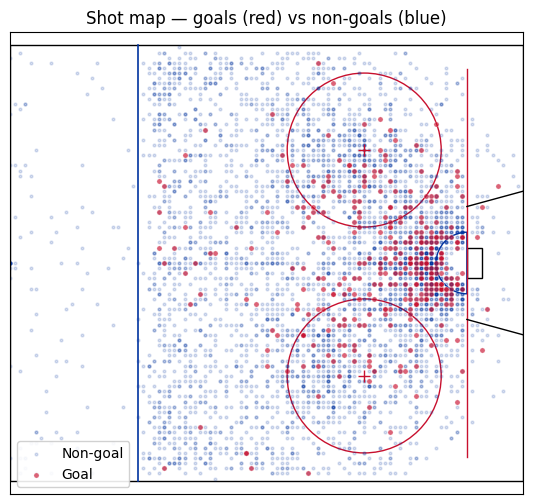

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_shot_map(features, ax=ax)
plt.show()

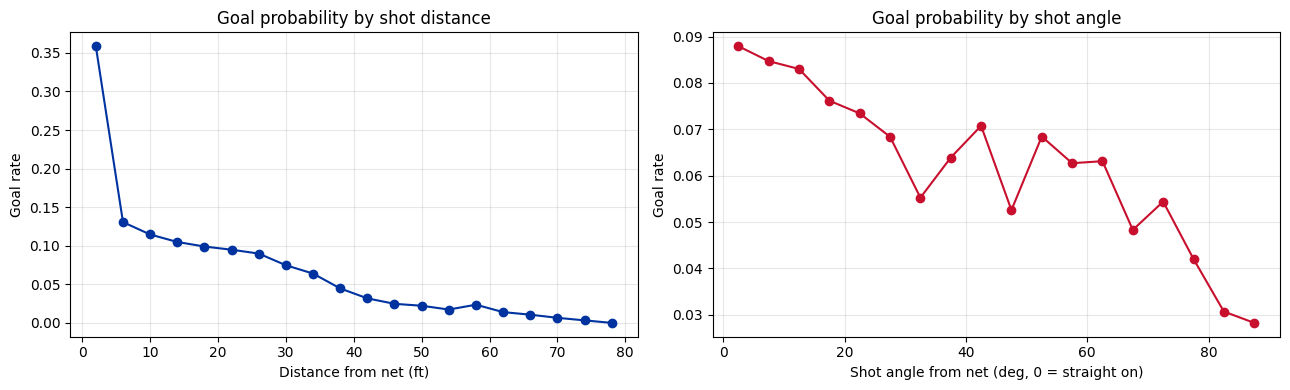

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
plot_goal_rate_by_distance(features, ax=axs[0])
plot_goal_rate_by_angle(features, ax=axs[1])
plt.tight_layout()
plt.show()

## 4. Train and evaluate the model

Logistic regression is the baseline because it gives interpretable coefficients and produces calibrated probabilities — critical for an xG model where a 0.05 prediction needs to mean a 5% long-run goal rate.

Features are standardized so coefficient *magnitudes* are directly comparable.

### Why accuracy is not the target metric

Goal prediction is a rare-event probability problem. In a typical NHL shot dataset, most shots do not become goals, so a model can get high accuracy by predicting "no goal" almost every time. That is not useful for expected goals. We care whether the model assigns honest probabilities and ranks better looks above weaker looks, which is why the notebook focuses on ROC-AUC, log loss, Brier score, and calibration.

A 0.5 classification threshold is not emphasized because most useful xG probabilities are far below 50%. Calibration, Brier score, log loss, and ROC-AUC are more meaningful than accuracy or a default confusion matrix.


In [10]:
X_train, X_test, y_train, y_test = split_data(features, feat_cols)
logreg = train_logistic(X_train, y_train)
metrics = evaluate(logreg, X_test, y_test)

print('Logistic regression probability metrics:')
for k in ['roc_auc', 'log_loss', 'brier', 'actual_goal_rate', 'predicted_goal_rate']:
    print(f'  {k}: {metrics[k]:.4f}')


Logistic regression probability metrics:
  roc_auc: 0.7395
  log_loss: 0.2259
  brier: 0.0607
  actual_goal_rate: 0.0682
  predicted_goal_rate: 0.0682


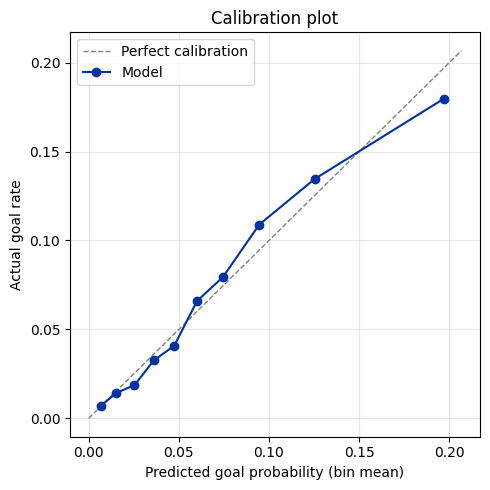

   n  mean_pred   actual
2305   0.006587 0.006941
2304   0.015382 0.014323
2304   0.025417 0.018663
2304   0.036103 0.032552
2304   0.047448 0.040799
2304   0.060105 0.065972
2304   0.074450 0.079427
2304   0.094621 0.108941
2304   0.125306 0.134549
2305   0.196847 0.179610


In [11]:
proba = logreg.predict_proba(X_test)[:, 1]
cal = calibration_table(y_test, proba, n_bins=10)

fig, ax = plt.subplots(figsize=(5, 5))
plot_calibration(cal, ax=ax)
plt.tight_layout()
plt.show()
print(cal.to_string(index=False))

In [12]:
coef_df = coefficient_table(logreg, feat_cols)
coef_df

,feature,coefficient
0,distance_sq,-0.452604
1,distance,-0.355193
2,angle_x_distance,-0.274853
3,shottype_TIP-IN,-0.273055
4,angle,-0.220673
5,log_distance,-0.180429
6,shottype_SNAP,0.148088
7,speed_from_last,-0.140964
8,shottype_SLAP,0.137086
9,angle_change,0.105820


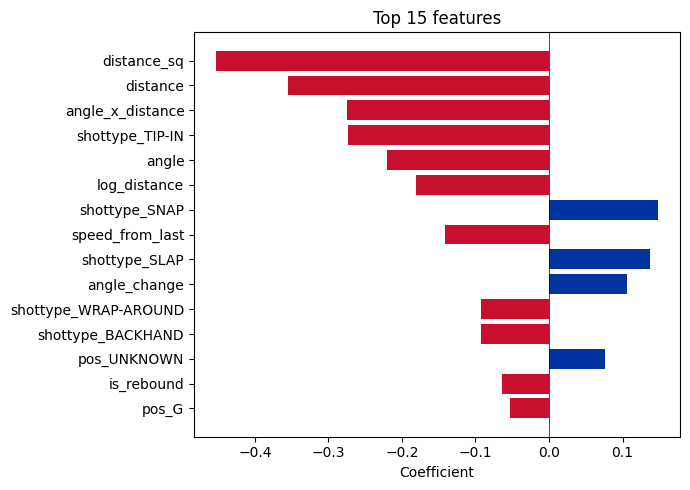

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_feature_importance(coef_df, top_n=min(15, len(coef_df)), ax=ax)
plt.tight_layout()
plt.show()

### Optional: gradient boosting comparison

Tree-based models can pick up non-linearity in distance directly, without relying as much on squared/log transforms. 

In [14]:
gb = train_gradient_boosting(X_train, y_train)
gb_metrics = evaluate(gb, X_test, y_test)
print(f'Logistic AUC:          {metrics["roc_auc"]:.4f}')
print(f'Gradient-boosted AUC:  {gb_metrics["roc_auc"]:.4f}')
print()
feature_importance_table(gb, feat_cols).head(10)

Logistic AUC:          0.7395
Gradient-boosted AUC:  0.7584



,feature,importance
0,distance,0.241860
1,angle_x_distance,0.170487
2,distance_sq,0.138536
3,speed_from_last,0.094597
4,shottype_TIP-IN,0.061173
5,angle_change,0.056570
6,log_distance,0.056488
7,angle,0.050984
8,shottype_SNAP,0.026198
9,is_rebound,0.015702


### Benchmark against MoneyPuck xGoal

MoneyPuck publishes its own `xGoal` column. If it is present, we compare this compact logistic baseline against MoneyPuck on the same held-out rows.

On the verified 2025 MoneyPuck file, MoneyPuck's published `xGoal` performed better than the project model: ROC-AUC 0.7694 vs. 0.7395, log loss 0.2178 vs. 0.2259, and Brier score 0.0587 vs. 0.0607. The project model trails MoneyPuck's published benchmark.


In [15]:
cols = detect_columns(features)
if 'xgoal' in cols:
    # Align to the same held-out rows used for our model.
    benchmark = features.loc[X_test.index, [cols['xgoal']]].copy()
    benchmark['our_model'] = logreg.predict_proba(X_test)[:, 1]
    benchmark['goal'] = y_test
    benchmark = benchmark.dropna()

    comparison = benchmark_probabilities(
        benchmark['goal'],
        benchmark['our_model'],
        benchmark[cols['xgoal']].astype(float),
        benchmark_name='MoneyPuck_xGoal',
    )
    display(comparison)

    ours = comparison[comparison['model'] == 'our_model'].iloc[0]
    mp = comparison[comparison['model'] == 'MoneyPuck_xGoal'].iloc[0]
    if mp['roc_auc'] > ours['roc_auc'] and mp['log_loss'] < ours['log_loss'] and mp['brier'] < ours['brier']:
        print('MoneyPuck xGoal is stronger on these held-out rows.')
    print('Interpretation: lower log loss/Brier is better; higher ROC-AUC is better.')
    print('Use the project model as an interpretable baseline, not a replacement for MoneyPuck xGoal.')
else:
    print('No xGoal column found - skipping MoneyPuck benchmark.')
    print('(This column is included in real MoneyPuck data but not the synthetic sample.)')


,model,roc_auc,log_loss,brier,mean_predicted
0,our_model,0.739484,0.225854,0.060687,0.068230
1,MoneyPuck_xGoal,0.769391,0.217821,0.058668,0.068594


MoneyPuck xGoal is stronger on these held-out rows.
Interpretation: lower log loss/Brier is better; higher ROC-AUC is better.
Use the project model as an interpretable baseline, not a replacement for MoneyPuck xGoal.


## 5. Where on the ice are the most dangerous shots?

Score every shot with the model and take the average predicted goal probability per location to make a danger heatmap.

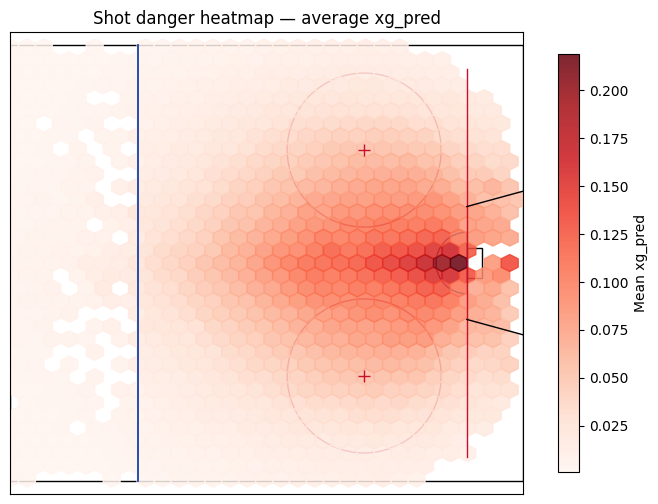

In [16]:
features['xg_pred'] = logreg.predict_proba(features[feat_cols])[:, 1]
fig, ax = plt.subplots(figsize=(9, 6))
plot_danger_heatmap(features, value='xg_pred', ax=ax)
plt.show()

In [17]:
# What does a high-danger shot look like in the data?
show_cols = ['distance', 'angle', 'is_rebound', 'is_rush', 'goal', 'xg_pred']
if 'shotType' in features.columns:
    show_cols.insert(0, 'shotType')
if 'shooterName' in features.columns:
    show_cols.insert(0, 'shooterName')
cols = detect_columns(features)
if 'xgoal' in cols:
    show_cols.append(cols['xgoal'])
features.nlargest(15, 'xg_pred')[show_cols].rename(columns={'is_rush': 'is_rush_sparse_proxy'})


,shooterName,shotType,distance,angle,is_rebound,is_rush_sparse_proxy,goal,xg_pred,xGoal
75636,Gabriel Vilardi,WRIST,6.082763,9.462322,0,0,0,0.548831,0.214563
66322,Viktor Arvidsson,SNAP,4.123106,14.036243,0,0,0,0.523679,0.285136
76923,Timo Meier,WRIST,3.162278,18.434949,1,0,1,0.480657,0.200287
75573,Juraj Slafkovsky,SNAP,19.000000,0.000000,0,0,0,0.478857,0.086756
76358,Nico Hischier,WRIST,3.162278,18.434949,0,0,0,0.477894,0.314810
69468,Jordan Eberle,WRIST,8.062258,7.125016,0,0,1,0.466244,0.061338
100073,Ryan McDonagh,SNAP,6.708204,26.565051,0,0,0,0.464506,0.289167
82638,Josh Doan,DEFL,7.280110,15.945396,0,0,0,0.460538,0.071398
110360,Claude Giroux,WRIST,8.062258,7.125016,0,0,0,0.457104,0.178874
80486,Matt Coronato,SNAP,4.123106,14.036243,0,0,0,0.456948,0.023651


## 6. Team example: Tampa Bay Lightning
In the verified 2025 MoneyPuck shot dataset, Tampa Bay generated slightly higher shot danger per shot than the rest of the league: about +0.003 to +0.004 xG per shot depending on whether using the project model or MoneyPuck's published `xGoal`.


In [18]:
cols = detect_columns(features)
team_col = cols.get('team_code')
mp_xg_col = cols.get('xgoal')
using_sample = path.name == 'sample_shots.csv'

if using_sample:
    print('Synthetic sample includes team labels, but this section is intended for real MoneyPuck data.')
    print('Skipping Tampa Bay conclusions until data/shots.csv is loaded.')
elif team_col is None:
    print('No team column found - skipping Tampa Bay example.')
else:
    team_codes = features[team_col].astype('string').str.strip().str.upper()
    if 'TBL' not in set(team_codes.dropna()):
        print('No TBL rows found in this dataset - skipping Tampa Bay example.')
    else:
        tbl = features[team_codes == 'TBL'].copy()
        league = features[team_codes != 'TBL'].copy()

        def summarize(group, label):
            row = {
                'group': label,
                'shots': len(group),
                'avg_project_xg': group['xg_pred'].mean(),
                'actual_goal_rate': group['goal'].mean(),
                'high_danger_share_10pct': (group['xg_pred'] >= 0.10).mean(),
                'avg_distance': group['distance'].mean(),
                'avg_angle': group['angle'].mean(),
                'rebound_share': group['is_rebound'].mean(),
                'rush_sparse_proxy_share': group['is_rush'].mean(),
            }
            if mp_xg_col is not None:
                row['avg_moneypuck_xgoal'] = group[mp_xg_col].astype(float).mean()
            return row

        comparison = pd.DataFrame([
            summarize(tbl, 'Tampa Bay'),
            summarize(league, 'Rest of league'),
        ])
        display(comparison.style.format({
            'avg_project_xg': '{:.4f}',
            'avg_moneypuck_xgoal': '{:.4f}',
            'actual_goal_rate': '{:.3f}',
            'high_danger_share_10pct': '{:.1%}',
            'avg_distance': '{:.1f}',
            'avg_angle': '{:.1f}',
            'rebound_share': '{:.1%}',
            'rush_sparse_proxy_share': '{:.3%}',
        }))

        project_diff = comparison.loc[0, 'avg_project_xg'] - comparison.loc[1, 'avg_project_xg']
        print(f"Project model: Tampa Bay was {project_diff:+.4f} xG/shot vs. the rest of the league.")
        if mp_xg_col is not None:
            mp_diff = comparison.loc[0, 'avg_moneypuck_xgoal'] - comparison.loc[1, 'avg_moneypuck_xgoal']
            print(f"MoneyPuck xGoal: Tampa Bay was {mp_diff:+.4f} xG/shot vs. the rest of the league.")

        tbl_rush_count = int(tbl['is_rush'].sum())
        print(f"Rush proxy caution: Tampa Bay has {tbl_rush_count} rush-flagged shots in this cleaned dataset.")
        print('Use video review to explain the why: entries, forecheck recoveries, net-front traffic, and rebound creation.')


,group,shots,avg_project_xg,actual_goal_rate,high_danger_share_10pct,avg_distance,avg_angle,rebound_share,rush_sparse_proxy_share,avg_moneypuck_xgoal
0,Tampa Bay,3845,0.0719,0.073,24.7%,33.2,31.4,8.6%,0.052%,0.0716
1,Rest of league,111362,0.0681,0.068,22.4%,33.1,33.3,8.1%,0.057%,0.0684


Project model: Tampa Bay was +0.0039 xG/shot vs. the rest of the league.
MoneyPuck xGoal: Tampa Bay was +0.0032 xG/shot vs. the rest of the league.
Rush proxy caution: Tampa Bay has 2 rush-flagged shots in this cleaned dataset.
Use video review to explain the why: entries, forecheck recoveries, net-front traffic, and rebound creation.


## 7. Coach-facing takeaways

- **Distance dominates.** Most of the goal probability lives near the net and in the slot. Perimeter volume needs additional context, such as traffic, rebound creation, or lateral movement, before treating it as dangerous.
- **Angle still matters after distance.** A 20-foot shot from the half-wall is not the same chance as a 20-foot shot from the slot.
- **Rebounds are supported in the raw data.** In the verified 2025 file, rebound shots scored at about 11.04% vs. 6.45% for non-rebound shots, but modeled rebound value depends on location, angle change, and rebound quality.
- **Shot type is context-dependent.** Deflections showed elevated raw scoring value, while tip-ins were more mixed after controlling for location and shot context.
- **Rush analysis needs caution.** The public `shotRush` flag is sparse in this dataset, so rush-related results should be treated as a rough proxy rather than a complete transition-offense measure.
- **MoneyPuck remains the stronger benchmark.** The compact logistic model trails MoneyPuck `xGoal`, but it is useful because it is transparent and coach-facing.

See `reports/coach_summary.md` for the longer-form writeup intended for non-technical readers.
